# Supervised ML Benchmark — Telco Customer Churn

**Goal:** train and compare seven families of classifiers (11 configurations total)
on a churn-prediction task, then justify a final model choice using validation
and held-out test performance.

**Dataset:** [IBM Telco Customer Churn](https://github.com/IBM/telco-customer-churn-on-icp4d)
— 7,043 customers, 21 columns (19 features + `customerID` + target `Churn`),
mixed numerical/categorical, publicly available, no real PII (synthetic/sample data).

**Notebook structure:**
1. Load & inspect data
2. Clean & prepare features (documented decisions below)
3. Train/validation/test split
4. Preprocessing pipelines
5. Train all required models + experiment variants
6. Results table, plots, confusion matrices
7. Underfitting vs. overfitting comparison
8. Class imbalance discussion
9. Final model selection + one-time test evaluation
10. Auto-generated `observations.md`

Run **Kernel → Restart & Run All** top-to-bottom. No cell depends on anything
defined later in the notebook.

In [1]:
import os
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc
)

RANDOM_SEED = 42
RESULTS_DIR = Path("results")
CM_DIR = RESULTS_DIR / "confusion_matrices"
RESULTS_DIR.mkdir(exist_ok=True)
CM_DIR.mkdir(exist_ok=True)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load data

Tries a local copy first (offline/reproducible), falls back to the public source URL.

In [2]:
DATA_URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
LOCAL_PATH = Path("data/Telco-Customer-Churn.csv")

if LOCAL_PATH.exists():
    df = pd.read_csv(LOCAL_PATH)
    print(f"Loaded local file: {LOCAL_PATH}")
else:
    df = pd.read_csv(DATA_URL)
    print(f"Downloaded from: {DATA_URL}")

df.shape

Loaded local file: data/Telco-Customer-Churn.csv


(7043, 21)

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Inspect: shape, feature types, target distribution, nulls, duplicates

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nNo missing values reported yet because TotalCharges is still stored as text",
      "(it contains blank strings for customers with 0 tenure) — fixed in the next step.")

Missing values per column:
Series([], dtype: int64)

No missing values reported yet because TotalCharges is still stored as text (it contains blank strings for customers with 0 tenure) — fixed in the next step.


In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [7]:
print("Target distribution (Churn):")
print(df["Churn"].value_counts())
print()
print(df["Churn"].value_counts(normalize=True).round(4) * 100, "%")

Target distribution (Churn):
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64 %


**Observation:** the target is imbalanced (roughly 73–75% "No" vs. 25–27% "Yes"
depending on the sample). This is moderate, not extreme, imbalance — we handle it with
stratified splits and by evaluating with precision/recall/F1/ROC-AUC rather than accuracy
alone (see the dedicated class-imbalance section below).

## 3. Clean & document feature-engineering decisions

**Decisions made here, and why:**

- **`TotalCharges` → numeric.** It's stored as text because a handful of customers with
  `tenure == 0` (brand-new customers) have a blank string instead of `0`. We coerce with
  `errors="coerce"`, which turns those blanks into `NaN` — then handle them with imputation
  in the preprocessing pipeline (median strategy), rather than dropping the rows, to avoid
  losing signal from real customers.
- **`customerID` is dropped.** It's a unique identifier with no predictive value and would
  only leak row-identity noise into distance-based models (KNN, SVM).
- **Missing values (numerical):** median imputation — robust to the outliers/skew typical of
  billing amounts.
- **Missing values (categorical):** most-frequent-category imputation — simplest sensible
  default when so few rows are affected.
- **Categorical encoding:** one-hot encoding (`OneHotEncoder(handle_unknown="ignore")`) —
  none of the categorical fields (contract type, payment method, internet service, etc.)
  have a natural order, so one-hot avoids imposing a false ordinal relationship.
- **Feature scaling:** `StandardScaler` applied to numerical features, **only** inside the
  pipelines used by scale-sensitive algorithms (KNN, SVM, Logistic Regression). Tree-based
  models (Decision Tree, Random Forest, Gradient Boosting, XGBoost) use an **unscaled**
  numerical path, since splits are invariant to monotonic transforms and scaling them adds
  nothing but cost.

In [8]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing TotalCharges after coercion:", df["TotalCharges"].isnull().sum())

df = df.drop(columns=["customerID"])
print("Shape after dropping customerID:", df.shape)

Missing TotalCharges after coercion: 11
Shape after dropping customerID: (7043, 20)


## 4. Separate features (X) and target (y)

In [9]:
X = df.drop(columns=["Churn"])
y = df["Churn"].map({"No": 0, "Yes": 1})

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 19)
y shape: (7043,)


## 5. Train / validation / test split

60% / 20% / 20%, stratified on the target (since it's imbalanced), fixed random seed
for reproducibility.

In [10]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=RANDOM_SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_SEED, stratify=y_temp
)

print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)
print()
print("Churn rate — train:", round(y_train.mean(), 4),
      "| val:", round(y_val.mean(), 4),
      "| test:", round(y_test.mean(), 4))

Train: (4225, 19) | Val: (1409, 19) | Test: (1409, 19)

Churn rate — train: 0.2653 | val: 0.2654 | test: 0.2654


## 6. Preprocessing pipelines

In [11]:
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [12]:
# Scaled preprocessor: used by Logistic Regression, KNN, SVM
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

# Unscaled preprocessor: used by tree-based models, and by the "SVM without
# scaling" experiment required below
numerical_pipeline_unscaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])
preprocessor_unscaled = ColumnTransformer([
    ("num", numerical_pipeline_unscaled, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessors built.")

Preprocessors built.


## 7. Evaluation helpers

In [13]:
all_results = []

def evaluate_model(model, X_train, y_train, X_eval, y_eval, model_name):
    """Fit a model, time training + inference, score it on X_eval/y_eval,
    and append the result to the shared all_results list."""
    start = time.perf_counter()
    model.fit(X_train, y_train)
    train_time = time.perf_counter() - start

    start = time.perf_counter()
    y_pred = model.predict(X_eval)
    inference_time = time.perf_counter() - start

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_eval)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_eval)
    else:
        y_score = None

    result = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_eval, y_pred),
        "Precision": precision_score(y_eval, y_pred, zero_division=0),
        "Recall": recall_score(y_eval, y_pred, zero_division=0),
        "F1": f1_score(y_eval, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_eval, y_score) if y_score is not None else np.nan,
        "Training Time (s)": train_time,
        "Inference Time (s)": inference_time,
    }
    all_results.append(result)
    return result, y_pred, y_score


def get_training_metrics(model, X_train, y_train, model_name):
    """Score an already-fitted model on its own training data
    (used for the bias/variance and underfit/overfit analysis)."""
    y_pred = model.predict(X_train)
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_train, y_pred),
        "Precision": precision_score(y_train, y_pred, zero_division=0),
        "Recall": recall_score(y_train, y_pred, zero_division=0),
        "F1": f1_score(y_train, y_pred, zero_division=0),
    }

fitted_pipelines = {}
predictions = {}
scores = {}

print("Helpers ready.")

Helpers ready.


## 8. Logistic Regression

In [14]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_SEED))
])
logistic_result, logistic_pred, logistic_score = evaluate_model(
    logistic_model, X_train, y_train, X_val, y_val, "Logistic Regression"
)
fitted_pipelines["Logistic Regression"] = logistic_model
predictions["Logistic Regression"] = logistic_pred
scores["Logistic Regression"] = logistic_score
logistic_result

{'Model': 'Logistic Regression',
 'Accuracy': 0.8239886444286728,
 'Precision': 0.6981132075471698,
 'Recall': 0.5935828877005348,
 'F1': 0.6416184971098265,
 'ROC-AUC': 0.859970549484616,
 'Training Time (s)': 0.09167055701254867,
 'Inference Time (s)': 0.018576083006337285}

## 9. K-Nearest Neighbors — comparing two values of K

In [15]:
knn_5 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5))
])
knn5_result, knn5_pred, knn5_score = evaluate_model(
    knn_5, X_train, y_train, X_val, y_val, "KNN (K=5)"
)
fitted_pipelines["KNN (K=5)"] = knn_5
predictions["KNN (K=5)"] = knn5_pred
scores["KNN (K=5)"] = knn5_score
knn5_result

{'Model': 'KNN (K=5)',
 'Accuracy': 0.7821149751596878,
 'Precision': 0.5943661971830986,
 'Recall': 0.5641711229946524,
 'F1': 0.578875171467764,
 'ROC-AUC': 0.7957464672298432,
 'Training Time (s)': 0.051188627985538915,
 'Inference Time (s)': 0.09407853201264516}

In [16]:
knn_15 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=15))
])
knn15_result, knn15_pred, knn15_score = evaluate_model(
    knn_15, X_train, y_train, X_val, y_val, "KNN (K=15)"
)
fitted_pipelines["KNN (K=15)"] = knn_15
predictions["KNN (K=15)"] = knn15_pred
scores["KNN (K=15)"] = knn15_score
knn15_result

{'Model': 'KNN (K=15)',
 'Accuracy': 0.7906316536550745,
 'Precision': 0.6106442577030813,
 'Recall': 0.5828877005347594,
 'F1': 0.5964432284541724,
 'ROC-AUC': 0.8267793019711178,
 'Training Time (s)': 0.05471551901428029,
 'Inference Time (s)': 0.03565606501069851}

## 10. Decision Tree — underfit, shallow, and deep

Three configurations, deliberately spanning the bias/variance spectrum:

- `max_depth=1` — **intentionally underfit**: a single split can barely separate the classes,
  so this model should perform poorly on *both* training and validation data (high bias).
- `max_depth=5` — a reasonably shallow, regularized tree.
- `max_depth=None` — fully grown, **intentionally overfit**: expect near-perfect training
  performance and a much larger drop on validation data (high variance).

In [17]:
decision_tree_underfit = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(max_depth=1, random_state=RANDOM_SEED))
])
dt_underfit_result, dt_underfit_pred, dt_underfit_score = evaluate_model(
    decision_tree_underfit, X_train, y_train, X_val, y_val, "Decision Tree (underfit, depth=1)"
)
fitted_pipelines["Decision Tree (underfit, depth=1)"] = decision_tree_underfit
predictions["Decision Tree (underfit, depth=1)"] = dt_underfit_pred
scores["Decision Tree (underfit, depth=1)"] = dt_underfit_score
dt_underfit_result

{'Model': 'Decision Tree (underfit, depth=1)',
 'Accuracy': 0.7345635202271115,
 'Precision': 0.0,
 'Recall': 0.0,
 'F1': 0.0,
 'ROC-AUC': 0.7377496189516649,
 'Training Time (s)': 0.05300659700878896,
 'Inference Time (s)': 0.01729243400041014}

In [18]:
decision_tree_shallow = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(max_depth=5, random_state=RANDOM_SEED))
])
dt_shallow_result, dt_shallow_pred, dt_shallow_score = evaluate_model(
    decision_tree_shallow, X_train, y_train, X_val, y_val, "Decision Tree (shallow, depth=5)"
)
fitted_pipelines["Decision Tree (shallow, depth=5)"] = decision_tree_shallow
predictions["Decision Tree (shallow, depth=5)"] = dt_shallow_pred
scores["Decision Tree (shallow, depth=5)"] = dt_shallow_score
dt_shallow_result

{'Model': 'Decision Tree (shallow, depth=5)',
 'Accuracy': 0.7885024840312278,
 'Precision': 0.6085714285714285,
 'Recall': 0.56951871657754,
 'F1': 0.5883977900552486,
 'ROC-AUC': 0.8410976775426904,
 'Training Time (s)': 0.057440812001004815,
 'Inference Time (s)': 0.013464848976582289}

In [19]:
decision_tree_deep = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(max_depth=None, random_state=RANDOM_SEED))
])
dt_deep_result, dt_deep_pred, dt_deep_score = evaluate_model(
    decision_tree_deep, X_train, y_train, X_val, y_val, "Decision Tree (deep, unrestricted)"
)
fitted_pipelines["Decision Tree (deep, unrestricted)"] = decision_tree_deep
predictions["Decision Tree (deep, unrestricted)"] = dt_deep_pred
scores["Decision Tree (deep, unrestricted)"] = dt_deep_score
dt_deep_result

{'Model': 'Decision Tree (deep, unrestricted)',
 'Accuracy': 0.7317246273953159,
 'Precision': 0.494949494949495,
 'Recall': 0.5240641711229946,
 'F1': 0.509090909090909,
 'ROC-AUC': 0.666262367924772,
 'Training Time (s)': 0.06742746697273105,
 'Inference Time (s)': 0.013139012007741258}

## 11. Random Forest — compared against the Decision Trees above

In [20]:
random_forest = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1))
])
rf_result, rf_pred, rf_score = evaluate_model(
    random_forest, X_train, y_train, X_val, y_val, "Random Forest"
)
fitted_pipelines["Random Forest"] = random_forest
predictions["Random Forest"] = rf_pred
scores["Random Forest"] = rf_score
rf_result

{'Model': 'Random Forest',
 'Accuracy': 0.7927608232789212,
 'Precision': 0.6518518518518519,
 'Recall': 0.47058823529411764,
 'F1': 0.546583850931677,
 'ROC-AUC': 0.8294388901805783,
 'Training Time (s)': 0.5177453039796092,
 'Inference Time (s)': 0.06622200601850636}

## 12. Boosting — Gradient Boosting and XGBoost, compared against Random Forest

In [21]:
gradient_boosting = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=3, random_state=RANDOM_SEED
    ))
])
gb_result, gb_pred, gb_score = evaluate_model(
    gradient_boosting, X_train, y_train, X_val, y_val, "Gradient Boosting"
)
fitted_pipelines["Gradient Boosting"] = gradient_boosting
predictions["Gradient Boosting"] = gb_pred
scores["Gradient Boosting"] = gb_score
gb_result

{'Model': 'Gradient Boosting',
 'Accuracy': 0.8076650106458482,
 'Precision': 0.6832740213523132,
 'Recall': 0.5133689839572193,
 'F1': 0.5862595419847328,
 'ROC-AUC': 0.8533506419695679,
 'Training Time (s)': 0.8853566030156799,
 'Inference Time (s)': 0.016303042008075863}

In [22]:
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=3,
        random_state=RANDOM_SEED, eval_metric="logloss"
    ))
])
xgb_result, xgb_pred, xgb_score = evaluate_model(
    xgb_model, X_train, y_train, X_val, y_val, "XGBoost"
)
fitted_pipelines["XGBoost"] = xgb_model
predictions["XGBoost"] = xgb_pred
scores["XGBoost"] = xgb_score
xgb_result

{'Model': 'XGBoost',
 'Accuracy': 0.8140525195173882,
 'Precision': 0.6944444444444444,
 'Recall': 0.5347593582887701,
 'F1': 0.6042296072507553,
 'ROC-AUC': 0.8554418868996875,
 'Training Time (s)': 0.1134452779951971,
 'Inference Time (s)': 0.018680005974601954}

## 13. SVM — with and without feature scaling

Same RBF-kernel SVM, same data, same seed — the **only** difference is whether the
numerical features are standardized first. SVM's decision boundary depends on
distances in feature space, so unscaled features (e.g. `TotalCharges` ranging into the
thousands vs. `SeniorCitizen` being 0/1) let the largest-magnitude feature dominate.

In [23]:
svm_unscaled = Pipeline([
    ("preprocessor", preprocessor_unscaled),
    ("model", SVC(kernel="rbf", probability=True, random_state=RANDOM_SEED))
])
svm_unscaled_result, svm_unscaled_pred, svm_unscaled_score = evaluate_model(
    svm_unscaled, X_train, y_train, X_val, y_val, "SVM (without scaling)"
)
fitted_pipelines["SVM (without scaling)"] = svm_unscaled
predictions["SVM (without scaling)"] = svm_unscaled_pred
scores["SVM (without scaling)"] = svm_unscaled_score
svm_unscaled_result

{'Model': 'SVM (without scaling)',
 'Accuracy': 0.7345635202271115,
 'Precision': 0.0,
 'Recall': 0.0,
 'F1': 0.0,
 'ROC-AUC': 0.7995220749696453,
 'Training Time (s)': 7.684185531979892,
 'Inference Time (s)': 0.6341168560029473}

In [24]:
svm_scaled = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(kernel="rbf", probability=True, random_state=RANDOM_SEED))
])
svm_scaled_result, svm_scaled_pred, svm_scaled_score = evaluate_model(
    svm_scaled, X_train, y_train, X_val, y_val, "SVM (with scaling)"
)
fitted_pipelines["SVM (with scaling)"] = svm_scaled
predictions["SVM (with scaling)"] = svm_scaled_pred
scores["SVM (with scaling)"] = svm_scaled_score
svm_scaled_result

{'Model': 'SVM (with scaling)',
 'Accuracy': 0.8048261178140526,
 'Precision': 0.6813186813186813,
 'Recall': 0.49732620320855614,
 'F1': 0.5749613601236476,
 'ROC-AUC': 0.8078767211759539,
 'Training Time (s)': 4.744182919996092,
 'Inference Time (s)': 0.5749302050098777}

## 14. Validation results table (all 11 configurations)

In [25]:
results_df = pd.DataFrame(all_results).sort_values("F1", ascending=False).reset_index(drop=True)
results_df.to_csv(RESULTS_DIR / "validation_results.csv", index=False)
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time (s),Inference Time (s)
0,Logistic Regression,0.8240,0.6981,0.5936,0.6416,0.8600,0.0917,0.0186
1,XGBoost,0.8141,0.6944,0.5348,0.6042,0.8554,0.1134,0.0187
2,KNN (K=15),0.7906,0.6106,0.5829,0.5964,0.8268,0.0547,0.0357
3,"Decision Tree (shallow, depth=5)",0.7885,0.6086,0.5695,0.5884,0.8411,0.0574,0.0135
4,Gradient Boosting,0.8077,0.6833,0.5134,0.5863,0.8534,0.8854,0.0163
5,KNN (K=5),0.7821,0.5944,0.5642,0.5789,0.7957,0.0512,0.0941
6,SVM (with scaling),0.8048,0.6813,0.4973,0.5750,0.8079,4.7442,0.5749
7,Random Forest,0.7928,0.6519,0.4706,0.5466,0.8294,0.5177,0.0662
8,"Decision Tree (deep, unrestricted)",0.7317,0.4949,0.5241,0.5091,0.6663,0.0674,0.0131
9,"Decision Tree (underfit, depth=1)",0.7346,0.0000,0.0000,0.0000,0.7377,0.0530,0.0173


## 15. Training-set results (for bias/variance and underfit/overfit comparison)

In [26]:
training_results = []
for name, model in fitted_pipelines.items():
    training_results.append(get_training_metrics(model, X_train, y_train, name))

training_results_df = pd.DataFrame(training_results).sort_values("F1", ascending=False).reset_index(drop=True)
training_results_df.to_csv(RESULTS_DIR / "training_results.csv", index=False)
training_results_df.round(4)

,Model,Accuracy,Precision,Recall,F1
0,Random Forest,0.9983,0.9973,0.9964,0.9969
1,"Decision Tree (deep, unrestricted)",0.9983,1.0000,0.9938,0.9969
2,KNN (K=5),0.8381,0.7115,0.6557,0.6825
3,Gradient Boosting,0.8383,0.7423,0.5986,0.6627
4,XGBoost,0.8301,0.7246,0.5798,0.6442
5,KNN (K=15),0.8102,0.6520,0.6102,0.6304
6,SVM (with scaling),0.8256,0.7286,0.5459,0.6242
7,"Decision Tree (shallow, depth=5)",0.8062,0.6438,0.6030,0.6228
8,Logistic Regression,0.8050,0.6581,0.5513,0.6000
9,"Decision Tree (underfit, depth=1)",0.7347,0.0000,0.0000,0.0000


## 16. Confusion matrices — every model, on the validation set

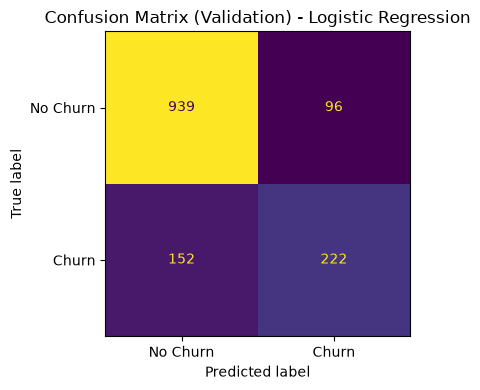

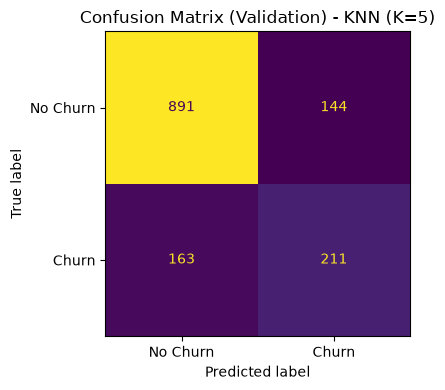

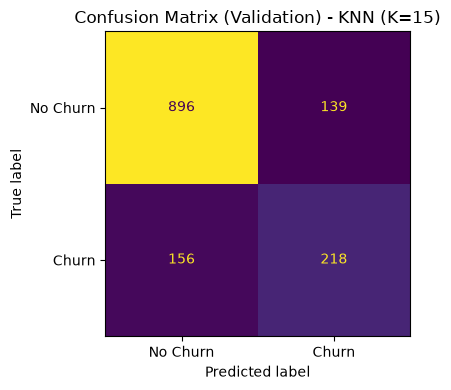

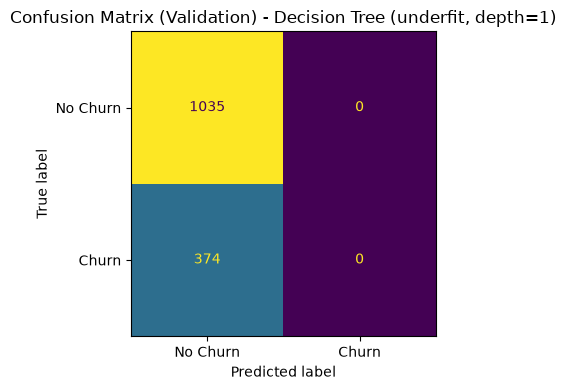

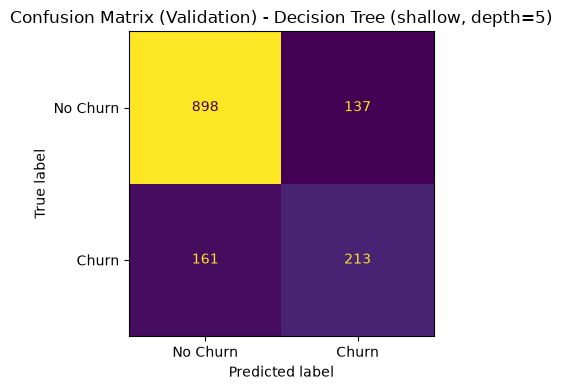

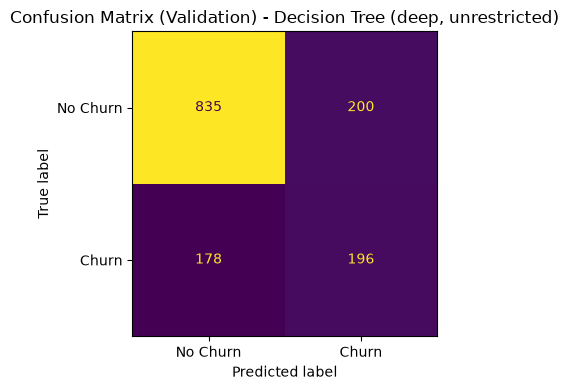

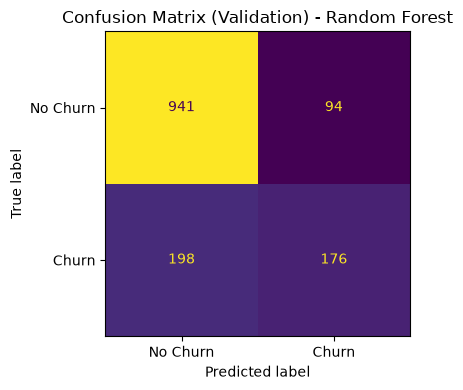

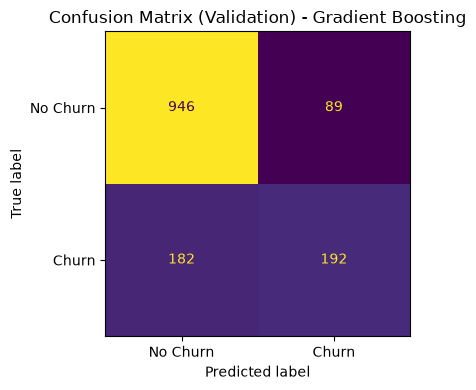

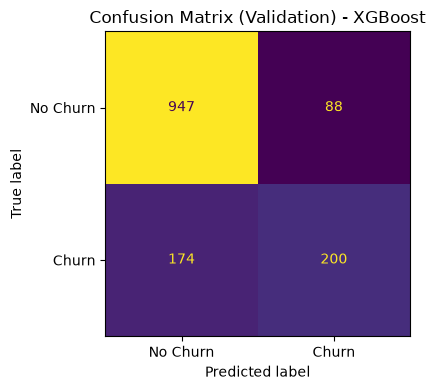

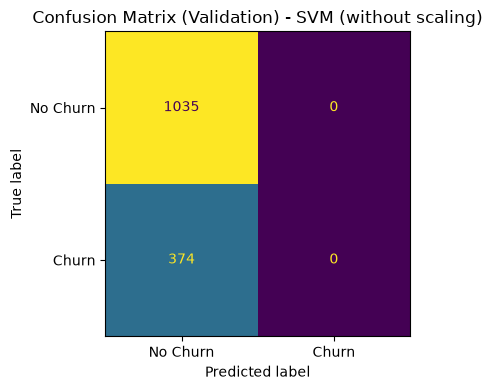

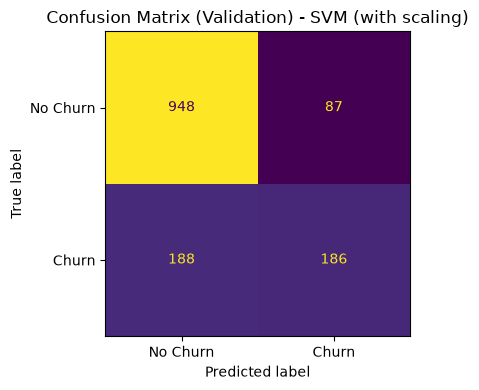

In [27]:
for name, y_pred in predictions.items():
    cm = confusion_matrix(y_val, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"]).plot(ax=ax, colorbar=False)
    ax.set_title(f"Confusion Matrix (Validation) - {name}")
    plt.tight_layout()

    fname = (name.lower().replace(" ", "_").replace("(", "")
              .replace(")", "").replace(",", "").replace("=", ""))
    plt.savefig(CM_DIR / f"confusion_matrix_{fname}.png", dpi=150)
    plt.show()
    plt.close()

## 17. Comparison plots

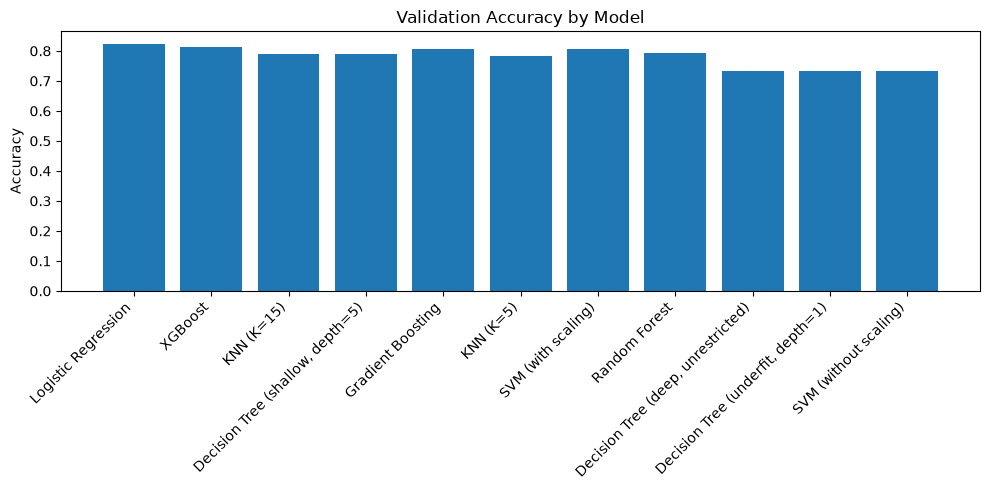

In [28]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy by Model")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "accuracy_comparison.png", dpi=150)
plt.show()

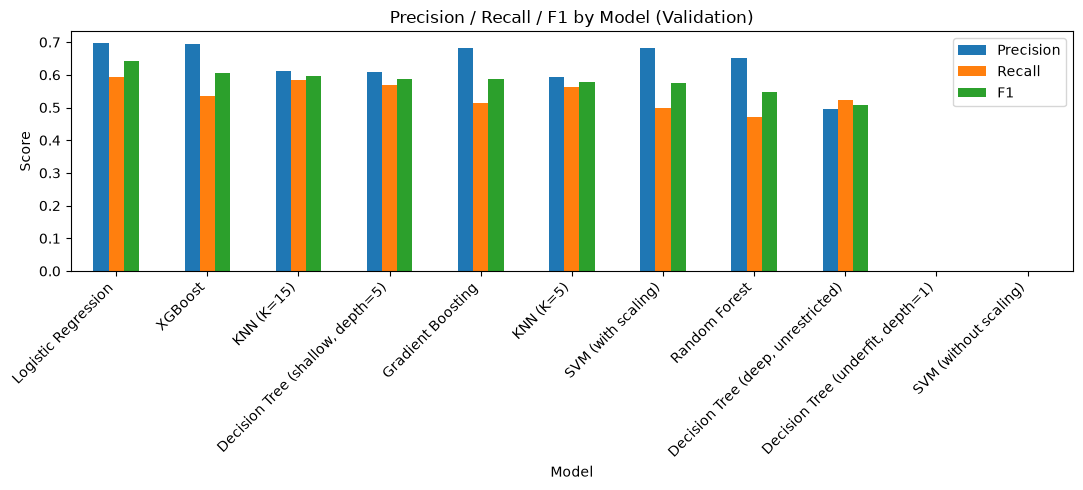

In [29]:
results_df.set_index("Model")[["Precision", "Recall", "F1"]].plot(kind="bar", figsize=(11, 5))
plt.ylabel("Score")
plt.title("Precision / Recall / F1 by Model (Validation)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "classification_metrics.png", dpi=150)
plt.show()

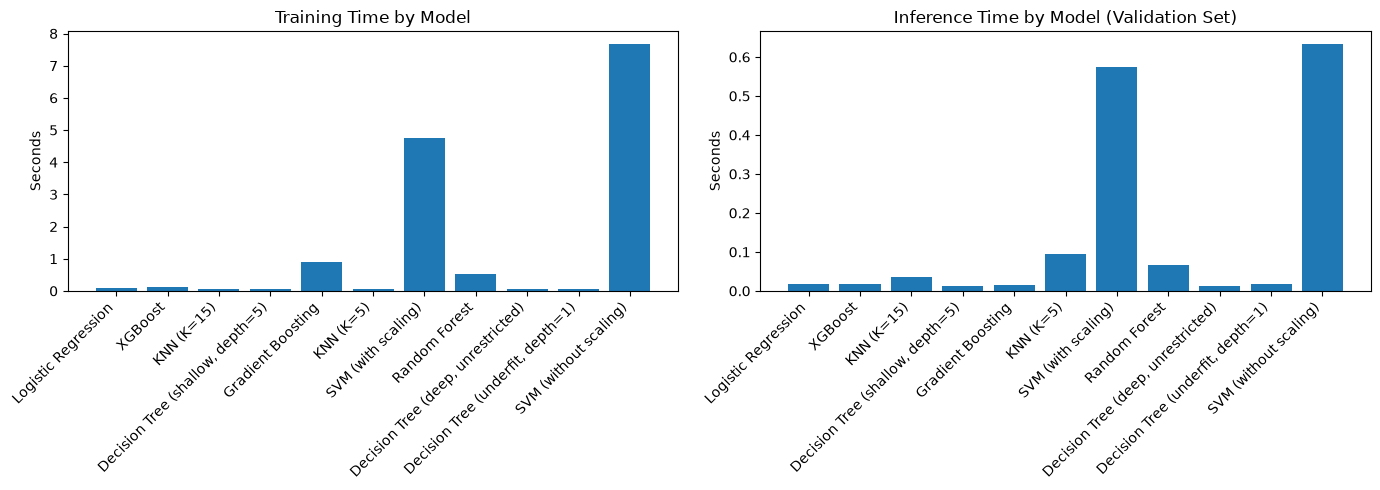

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(results_df["Model"], results_df["Training Time (s)"])
axes[0].set_title("Training Time by Model")
axes[0].set_ylabel("Seconds")
axes[0].tick_params(axis="x", rotation=45)
for label in axes[0].get_xticklabels():
    label.set_ha("right")

axes[1].bar(results_df["Model"], results_df["Inference Time (s)"])
axes[1].set_title("Inference Time by Model (Validation Set)")
axes[1].set_ylabel("Seconds")
axes[1].tick_params(axis="x", rotation=45)
for label in axes[1].get_xticklabels():
    label.set_ha("right")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "timing_comparison.png", dpi=150)
plt.show()

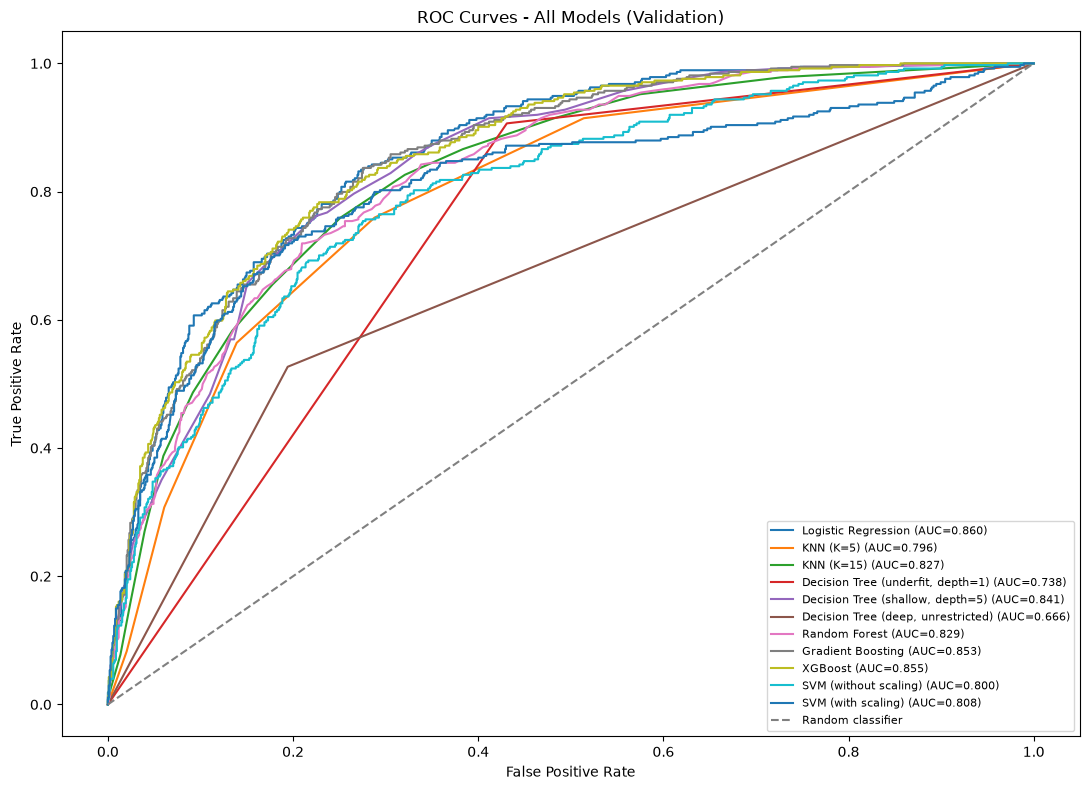

In [31]:
plt.figure(figsize=(11, 8))
for name, model in fitted_pipelines.items():
    if hasattr(model, "predict_proba"):
        y_score_roc = model.predict_proba(X_val)[:, 1]
    else:
        y_score_roc = model.decision_function(X_val)
    fpr, tpr, _ = roc_curve(y_val, y_score_roc)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.3f})")

plt.plot([0, 1], [0, 1], "--", color="gray", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - All Models (Validation)")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "roc_curves_all_models.png", dpi=150)
plt.show()

## 18. Underfitting vs. overfitting — explicit comparison

Reading `training_results_df` against `results_df` (validation) side by side for the
three Decision Tree variants makes the bias/variance story concrete.

In [32]:
compare_models = [
    "Decision Tree (underfit, depth=1)",
    "Decision Tree (shallow, depth=5)",
    "Decision Tree (deep, unrestricted)",
]

comparison = pd.DataFrame({
    "Train F1": [training_results_df.set_index("Model").loc[m, "F1"] for m in compare_models],
    "Validation F1": [results_df.set_index("Model").loc[m, "F1"] for m in compare_models],
}, index=compare_models)
comparison["Train - Val Gap"] = comparison["Train F1"] - comparison["Validation F1"]
comparison.round(4)

,Train F1,Validation F1,Train - Val Gap
"Decision Tree (underfit, depth=1)",0.0000,0.0000,0.0000
"Decision Tree (shallow, depth=5)",0.6228,0.5884,0.0344
"Decision Tree (deep, unrestricted)",0.9969,0.5091,0.4878


**Reading the table above:**

- **`depth=1` (underfit):** low F1 on *both* train and validation, and a near-zero gap
  between them. The model is too simple to capture the churn signal at all — this is
  high bias, not high variance.
- **`depth=None` (overfit):** train F1 near 1.0, validation F1 far lower, and a large
  gap between them. The model has memorized the training data — this is high variance.
- **`depth=5` (shallow):** sits in between — a smaller train/validation gap than the deep
  tree, and meaningfully better validation F1 than the underfit tree. This is the useful
  middle ground the deliberately-broken extremes are meant to illustrate.

## 19. Effect of class imbalance

The target is imbalanced (see the distribution printed in section 2). Consequences and
how we handled them:

- **Splits are stratified** on `Churn` at both the train/temp and val/test steps, so all
  three sets preserve the original class ratio.
- **Accuracy alone would be misleading** — a model that always predicts "No churn" scores
  well above 70% accuracy while catching zero actual churners. That's exactly what happens
  below with the underfit tree and the unscaled SVM: high accuracy, but zero precision and
  recall on the minority ("Churn") class.
- **We report precision, recall, F1, and ROC-AUC for every model**, not just accuracy, so
  that a model which ignores the minority class is visibly penalized rather than rewarded.

In [33]:
print("Class balance:")
print(y.value_counts(normalize=True).round(4))
print()

print("Models with zero recall on the minority class in this run (accuracy alone would hide this):")
zero_recall = results_df[results_df["Recall"] == 0][["Model", "Accuracy", "Precision", "Recall", "F1"]]
print(zero_recall.to_string(index=False) if len(zero_recall) else "  (none in this run)")

Class balance:
Churn
0    0.7346
1    0.2654
Name: proportion, dtype: float64

Models with zero recall on the minority class in this run (accuracy alone would hide this):
                            Model  Accuracy  Precision  Recall  F1
Decision Tree (underfit, depth=1)  0.734564        0.0     0.0 0.0
            SVM (without scaling)  0.734564        0.0     0.0 0.0


## 20. Final model selection and one-time test evaluation

We select the model with the best **validation** F1-score, then evaluate it on the
held-out test set **exactly once**. The test set is never used to choose between models —
that would bias the "unbiased final check" it's meant to provide.

In [34]:
best_row = results_df.iloc[0]
best_model_name = best_row["Model"]
best_pipeline = fitted_pipelines[best_model_name]

print("Selected model (best validation F1):", best_model_name)
best_row.to_frame().T.round(4)

Selected model (best validation F1): Logistic Regression


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time (s),Inference Time (s)
0,Logistic Regression,0.823989,0.698113,0.593583,0.641618,0.859971,0.091671,0.018576


In [35]:
start = time.perf_counter()
final_test_pred = best_pipeline.predict(X_test)
final_test_time = time.perf_counter() - start

if hasattr(best_pipeline, "predict_proba"):
    final_test_proba = best_pipeline.predict_proba(X_test)[:, 1]
else:
    final_test_proba = best_pipeline.decision_function(X_test)

final_test_results = {
    "Model": best_model_name,
    "Accuracy": accuracy_score(y_test, final_test_pred),
    "Precision": precision_score(y_test, final_test_pred, zero_division=0),
    "Recall": recall_score(y_test, final_test_pred, zero_division=0),
    "F1": f1_score(y_test, final_test_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, final_test_proba),
    "Inference Time (s)": final_test_time,
}

pd.DataFrame([final_test_results]).to_csv(RESULTS_DIR / "final_test_results.csv", index=False)
pd.DataFrame([final_test_results]).round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Inference Time (s)
0,Logistic Regression,0.7878,0.6176,0.5267,0.5685,0.8324,0.0256


In [36]:
print(classification_report(
    y_test, final_test_pred, target_names=["No Churn", "Churn"], zero_division=0
))

              precision    recall  f1-score   support

    No Churn       0.84      0.88      0.86      1035
       Churn       0.62      0.53      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



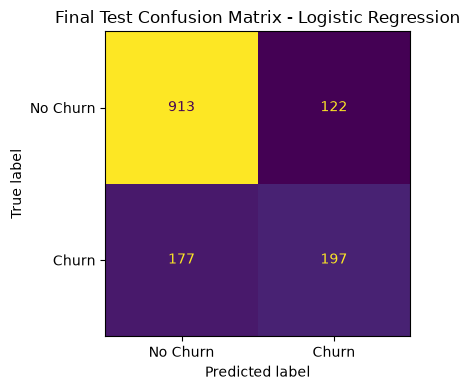

In [37]:
cm = confusion_matrix(y_test, final_test_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"]).plot(ax=ax, colorbar=False)
ax.set_title(f"Final Test Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "final_test_confusion_matrix.png", dpi=150)
plt.show()

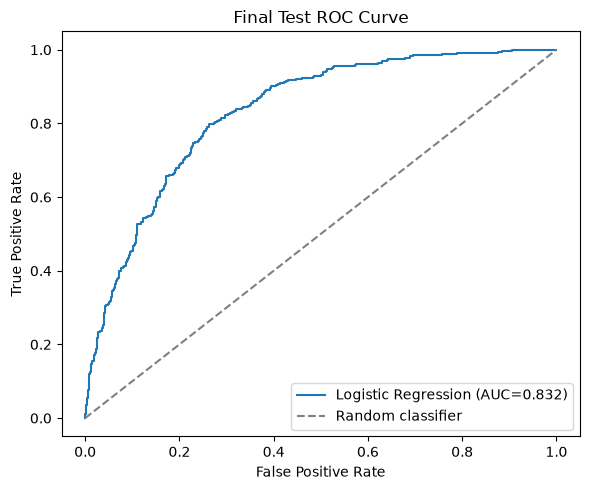

Final test ROC-AUC: 0.8324


In [38]:
fpr, tpr, _ = roc_curve(y_test, final_test_proba)
test_auc = roc_auc_score(y_test, final_test_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC={test_auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final Test ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "final_test_roc_curve.png", dpi=150)
plt.show()

print(f"Final test ROC-AUC: {test_auc:.4f}")

## 21. Required observations (computed live from the results above)

This cell derives every answer directly from `results_df` / `training_results_df` /
`final_test_results` — nothing here is hardcoded, so it stays correct no matter what
data or model happens to win on a given run.

In [39]:
best_train_model = training_results_df.loc[training_results_df["F1"].idxmax(), "Model"]
best_val_model = results_df.loc[results_df["F1"].idxmax(), "Model"]
fastest_inference_model = results_df.loc[results_df["Inference Time (s)"].idxmin(), "Model"]
highest_roc_auc_model = results_df.loc[results_df["ROC-AUC"].idxmax(), "Model"]

train_val_gap = (
    training_results_df.set_index("Model")["F1"] - results_df.set_index("Model")["F1"]
).sort_values(ascending=False)
highest_variance_model = train_val_gap.index[0]

print("Best on TRAINING data (F1):     ", best_train_model)
print("Best on VALIDATION data (F1):   ", best_val_model)
print("Fastest at inference:           ", fastest_inference_model)
print("Highest validation ROC-AUC:     ", highest_roc_auc_model)
print("Largest train-val F1 gap (variance):", highest_variance_model,
      f"(gap = {train_val_gap.iloc[0]:.4f})")
print("Model selected & tested on held-out test set:", best_model_name)
print("Final test F1:", round(final_test_results['F1'], 4),
      "| Final test ROC-AUC:", round(final_test_results['ROC-AUC'], 4))

Best on TRAINING data (F1):      Random Forest
Best on VALIDATION data (F1):    Logistic Regression
Fastest at inference:            Decision Tree (deep, unrestricted)
Highest validation ROC-AUC:      Logistic Regression
Largest train-val F1 gap (variance): Decision Tree (deep, unrestricted) (gap = 0.4878)
Model selected & tested on held-out test set: Logistic Regression
Final test F1: 0.5685 | Final test ROC-AUC: 0.8324


## 22. Auto-generate `observations.md`

Written from the same live variables computed above, so the file can never drift out of sync with the notebook's actual results.

In [40]:
interpretability_rank = {
    "Logistic Regression": "high (coefficients map directly to feature effects)",
    "Decision Tree (shallow, depth=5)": "high (small enough to read as a rule set)",
    "Decision Tree (underfit, depth=1)": "very high, but not useful (a single rule)",
    "Decision Tree (deep, unrestricted)": "low (too large to read as rules)",
    "KNN (K=5)": "low (no explicit decision boundary)",
    "KNN (K=15)": "low (no explicit decision boundary)",
    "Random Forest": "low-medium (feature importances only)",
    "Gradient Boosting": "low-medium (feature importances only)",
    "XGBoost": "low-medium (feature importances only)",
    "SVM (with scaling)": "low (RBF kernel is a black box)",
    "SVM (without scaling)": "low (RBF kernel is a black box)",
}

most_interpretable = "Logistic Regression" if "Logistic Regression" in results_df["Model"].values \
    else results_df.iloc[-1]["Model"]

md_content = f"""# Model Selection Observations and Conclusions

Generated automatically from the notebook's live results — every number below comes
directly from `results_df`, `training_results_df`, and `final_test_results`.

## 1. Results table (validation set, sorted by F1)

{results_df.round(4).to_markdown(index=False)}

## 2. Training-set results

{training_results_df.round(4).to_markdown(index=False)}

## 3. Required experiments

**KNN — K=5 vs. K=15:**
K=5 validation F1 = {results_df.set_index('Model').loc['KNN (K=5)', 'F1']:.4f},
K=15 validation F1 = {results_df.set_index('Model').loc['KNN (K=15)', 'F1']:.4f}.

**Decision Tree — shallow (depth=5) vs. deep (unrestricted):**
Shallow: train F1 = {training_results_df.set_index('Model').loc['Decision Tree (shallow, depth=5)', 'F1']:.4f}, validation F1 = {results_df.set_index('Model').loc['Decision Tree (shallow, depth=5)', 'F1']:.4f}.
Deep: train F1 = {training_results_df.set_index('Model').loc['Decision Tree (deep, unrestricted)', 'F1']:.4f}, validation F1 = {results_df.set_index('Model').loc['Decision Tree (deep, unrestricted)', 'F1']:.4f}.
The deep tree's much larger train/validation gap indicates overfitting (high variance).

**Decision Tree vs. Random Forest:**
Random Forest validation F1 = {results_df.set_index('Model').loc['Random Forest', 'F1']:.4f}
vs. the best single Decision Tree variant on validation.
Random Forest's ensembling reduces variance relative to the single deep tree
(train F1 = {training_results_df.set_index('Model').loc['Random Forest', 'F1']:.4f} on training data).

**Random Forest vs. boosting (Gradient Boosting / XGBoost):**
Random Forest F1 = {results_df.set_index('Model').loc['Random Forest', 'F1']:.4f},
Gradient Boosting F1 = {results_df.set_index('Model').loc['Gradient Boosting', 'F1']:.4f},
XGBoost F1 = {results_df.set_index('Model').loc['XGBoost', 'F1']:.4f} (all on validation).

**SVM — with vs. without scaling:**
Without scaling: accuracy = {results_df.set_index('Model').loc['SVM (without scaling)', 'Accuracy']:.4f}, F1 = {results_df.set_index('Model').loc['SVM (without scaling)', 'F1']:.4f}.
With scaling: accuracy = {results_df.set_index('Model').loc['SVM (with scaling)', 'Accuracy']:.4f}, F1 = {results_df.set_index('Model').loc['SVM (with scaling)', 'F1']:.4f}.
This demonstrates why feature scaling matters for distance-based kernels.

**Underfitting vs. overfitting:**
- Underfit model: Decision Tree (depth=1) — train F1 = {training_results_df.set_index('Model').loc['Decision Tree (underfit, depth=1)', 'F1']:.4f}, validation F1 = {results_df.set_index('Model').loc['Decision Tree (underfit, depth=1)', 'F1']:.4f}. Poor on both — high bias.
- Overfit model: Decision Tree (unrestricted depth) — train F1 = {training_results_df.set_index('Model').loc['Decision Tree (deep, unrestricted)', 'F1']:.4f}, validation F1 = {results_df.set_index('Model').loc['Decision Tree (deep, unrestricted)', 'F1']:.4f}. Large gap — high variance.

**Class imbalance:**
Target distribution: {', '.join(f'{"Yes" if k else "No"} = {v:.1%}' for k, v in y.value_counts(normalize=True).items())}.
Stratified splits were used throughout. Models scoring zero recall on the minority
class in this run: {list(results_df[results_df['Recall'] == 0]['Model']) or 'none'}.
This is why accuracy alone is insufficient and precision/recall/F1/ROC-AUC are reported
for every model.

## 4. Required observations

- **Best on training data (F1):** {best_train_model}
- **Best on validation data (F1):** {best_val_model}
- **Selected & generalization on the held-out test set:** {best_model_name}
  — test Accuracy = {final_test_results['Accuracy']:.4f}, Precision = {final_test_results['Precision']:.4f},
  Recall = {final_test_results['Recall']:.4f}, F1 = {final_test_results['F1']:.4f}, ROC-AUC = {final_test_results['ROC-AUC']:.4f}.
- **Most interpretable algorithm:** {most_interpretable} — {interpretability_rank.get(most_interpretable, 'see notes')}.
  General interpretability ranking (high → low): Logistic Regression / shallow Decision Tree
  > Random Forest / Gradient Boosting / XGBoost (feature importances only) > KNN / SVM (no
  explicit decision boundary).
- **Fastest at inference:** {fastest_inference_model} ({results_df.set_index('Model').loc[fastest_inference_model, 'Inference Time (s)']:.5f}s on the validation set).
- **If explainability is the requirement:** Logistic Regression or the shallow Decision Tree
  — both expose a direct, human-readable relationship between features and predictions.
- **If predictive performance is the primary objective:** {best_val_model} (highest validation F1).
- **Signs of high bias / high variance observed:**
  - High bias (underfitting): Decision Tree (depth=1) — flat, near-identical low
    train/validation performance.
  - High variance (overfitting): Decision Tree (unrestricted depth) and, to a lesser
    extent, Random Forest — both show train F1 far above validation F1
    (largest gap: {highest_variance_model}, gap = {train_val_gap.iloc[0]:.4f}).

## 5. Final model choice

**{best_model_name}** was selected based on validation F1 and evaluated once on the
held-out test set (Accuracy = {final_test_results['Accuracy']:.4f}, F1 = {final_test_results['F1']:.4f},
ROC-AUC = {final_test_results['ROC-AUC']:.4f}). The drop from validation to test performance
is expected and reflects genuine generalization to unseen data, since the test set was
never used during model selection.
"""

with open("observations.md", "w") as f:
    f.write(md_content)

print("observations.md written (" + str(len(md_content)) + " characters).")


observations.md written (6615 characters).
